---

## Dataset Overview: *Students Social Media Addiction*

This dataset contains detailed information about **705 students**, including their demographics, academic level, psychological well-being, and social media usage patterns. The main goal of the dataset is to assess the factors that contribute to **social media addiction** among students and allow predictive modeling using machine learning techniques.

---

## Column Descriptions (Features)

| Feature Name                       | Type        | Description                                                                                                                                                             |
| ---------------------------------- | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Student\_ID**                    | Integer     | A unique identifier assigned to each student (used only for indexing; not predictive).                                                                                  |
| **Age**                            | Integer     | The student’s age in years. Age typically ranges from 18 to 24.                                                                                                         |
| **Gender**                         | Categorical | Gender of the student. Values may include 'Male', 'Female', etc.                                                                                                        |
| **Academic\_Level**                | Categorical | The current level of academic study (e.g., Undergraduate, Postgraduate).                                                                                                |
| **Country**                        | Categorical | The country of residence of the student. This may reflect cultural or regional usage habits.                                                                            |
| **Avg\_Daily\_Usage\_Hours**       | Float       | Average number of hours per day the student spends on social media. This is a key behavioral variable.                                                                  |
| **Most\_Used\_Platform**           | Categorical | The primary social media platform used by the student (e.g., Instagram, TikTok, Facebook).                                                                              |
| **Affects\_Academic\_Performance** | Categorical | Indicates whether the student believes social media has a negative impact on their academic performance. Typically 'Yes' or 'No'.                                       |
| **Sleep\_Hours\_Per\_Night**       | Float       | Average number of hours the student sleeps per night. Sleep can correlate with both mental health and addiction.                                                        |
| **Mental\_Health\_Score**          | Integer     | A numerical score indicating the student's mental well-being. Ranges typically from 0 (poor) to 10 (excellent).                                                         |
| **Relationship\_Status**           | Categorical | Whether the student is single, in a relationship, married, etc. May influence social media usage habits.                                                                |
| **Conflicts\_Over\_Social\_Media** | Integer     | Number of times the student has had arguments or issues with others due to social media use. Indicates social impact.                                                   |
| **Addicted\_Score**                | Integer     | A score from 1 to 10 representing the level of social media addiction. This is the key outcome variable used for prediction. Higher values indicate stronger addiction. |

---

# Import Required Libraries

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix, 
    accuracy_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Step 1: Load and Clean Dataset

In [5]:
df = pd.read_csv("Students Social Media Addiction.csv")

In [6]:
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# Step 2: Data Overview

In [7]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [8]:
df.shape

(705, 13)

In [9]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [11]:
 df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

#  Step 3: Visualize Missing Values

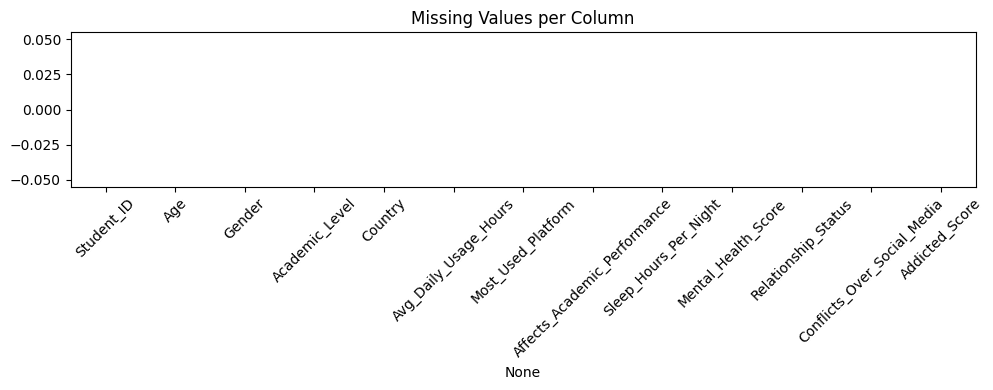

In [12]:
plt.figure(figsize=(10, 4))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.title("Missing Values per Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: Target Variable Distribution

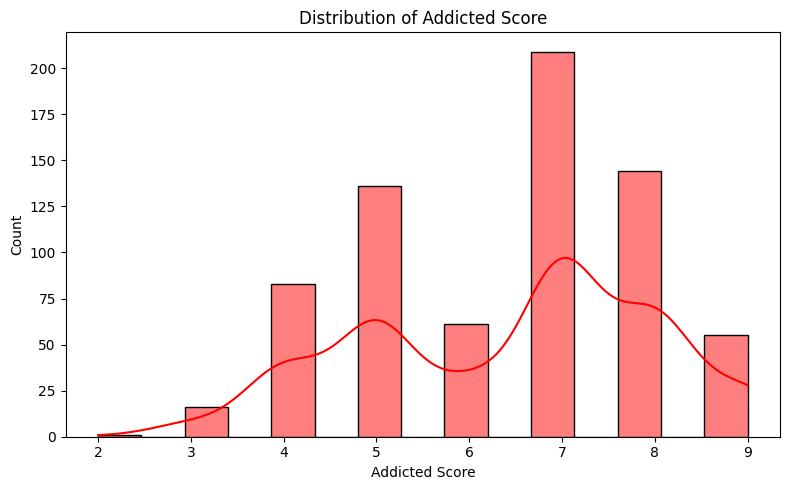

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Addicted_Score"], bins=15, kde=True, color="red")
plt.title("Distribution of Addicted Score")
plt.xlabel("Addicted Score")
plt.tight_layout()
plt.show()

# Step 5: Categorical Variables Distribution

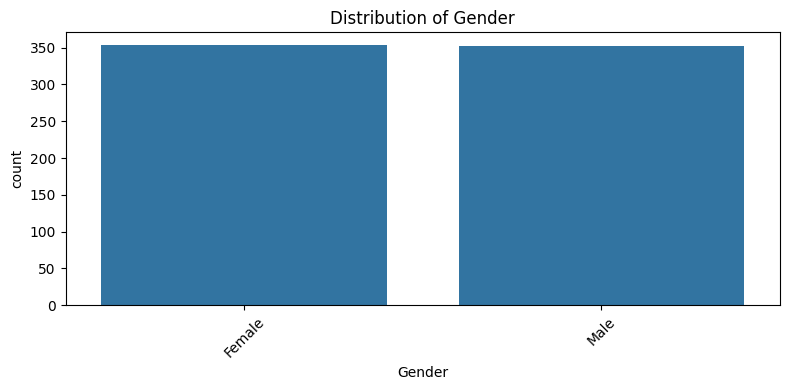

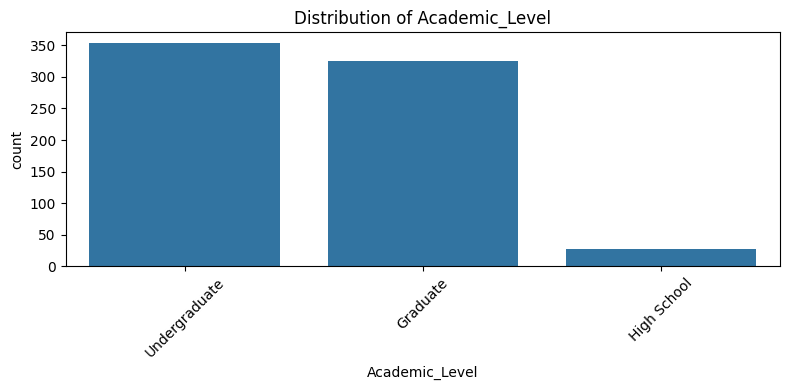

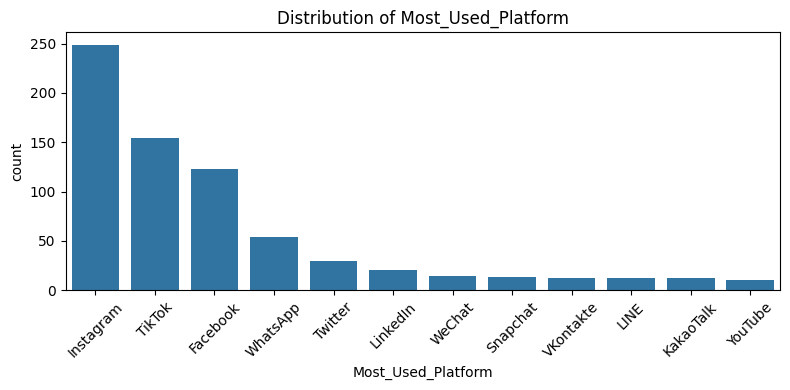

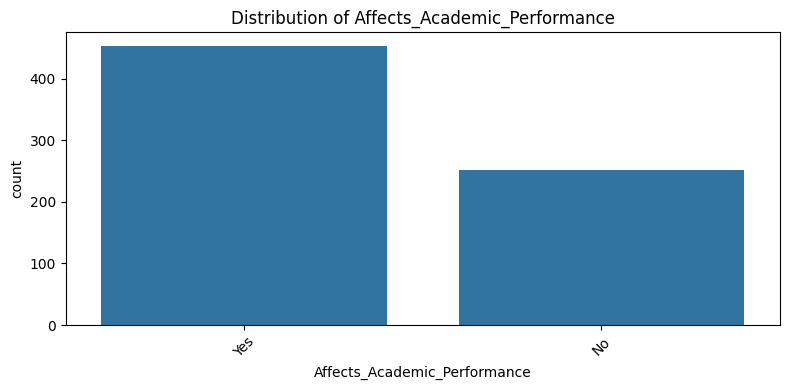

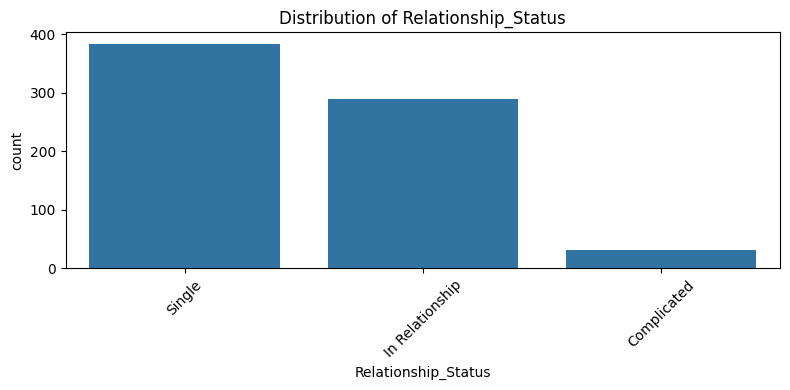

In [14]:
categorical_columns = [
    "Gender", "Academic_Level",
    "Most_Used_Platform", "Affects_Academic_Performance",
    "Relationship_Status"
]

for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Step 6: Correlation Analysis

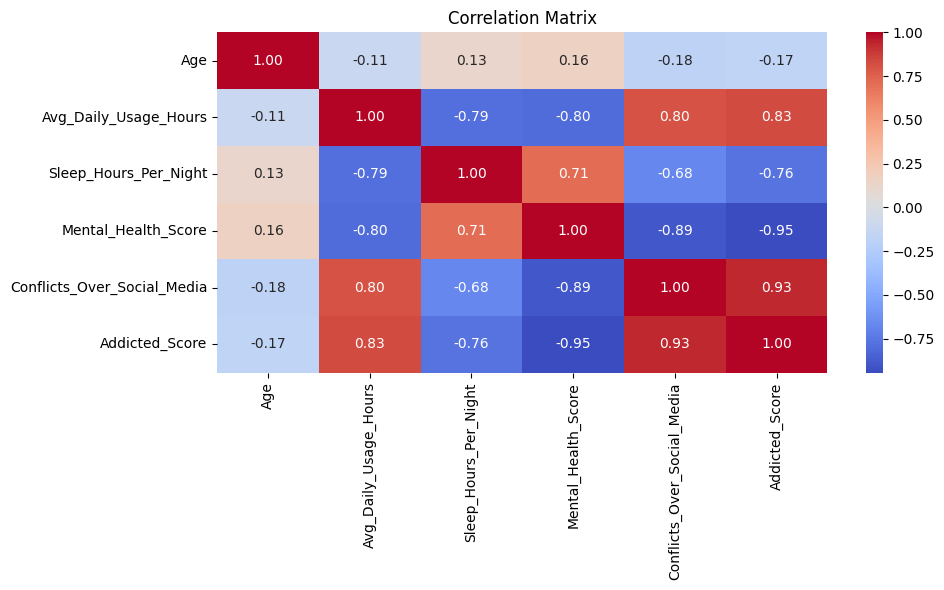

In [15]:
numeric_columns = [
    "Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
    "Mental_Health_Score", "Conflicts_Over_Social_Media", "Addicted_Score"
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Step 7: Boxplots for Outliers

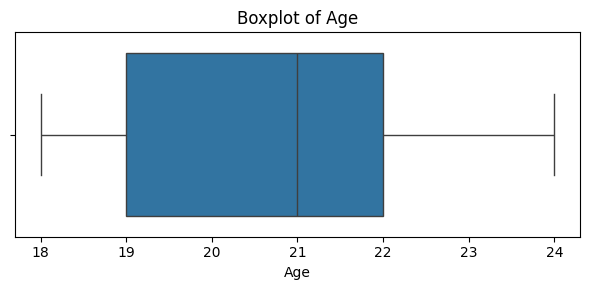

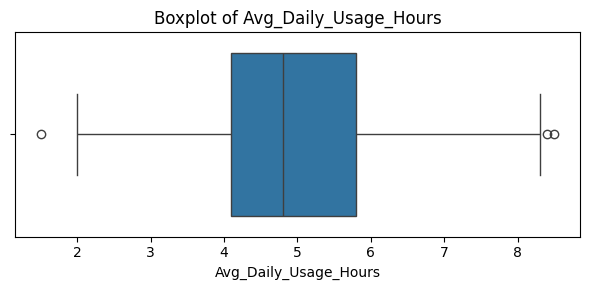

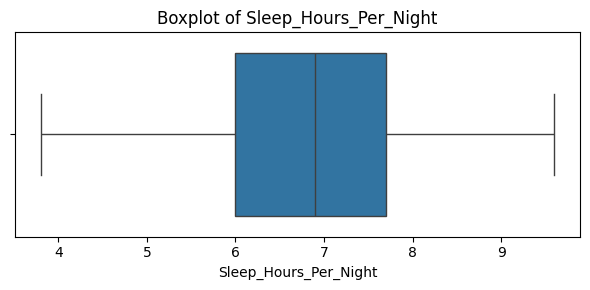

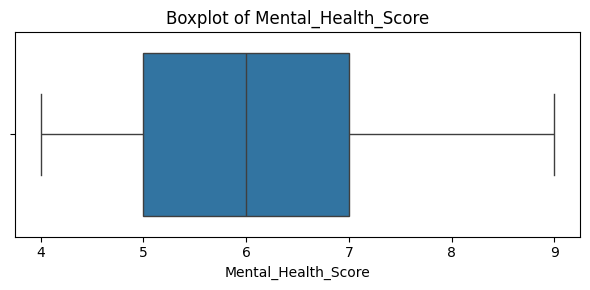

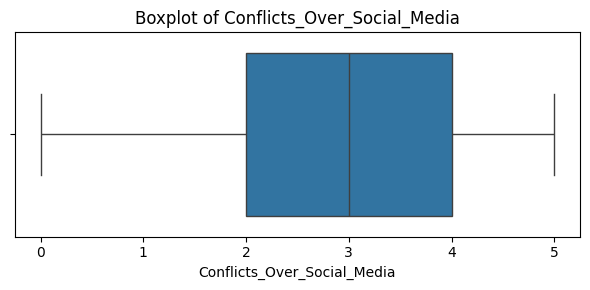

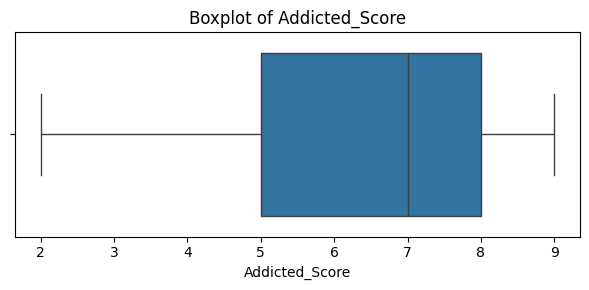

In [16]:
for col in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# Step 8: Feature Engineering

In [17]:
df.drop("Student_ID", axis=1, inplace=True)

## Encode all categorical columns automatically

In [18]:
object_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in object_cols:
    df[col] = le.fit_transform(df[col])

## Create binary classification target from Addicted_Score

In [19]:
df["Target"] = df["Addicted_Score"].apply(lambda x: 1 if x >= 7 else 0)

# Step 9: Define features and label

In [20]:
X = df.drop(["Addicted_Score", "Target"], axis=1)
y = df["Target"]

#  Step 10: Normalize Data

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 11: Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=537, stratify=y
)

# Step 12: Train 3 ML Models

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svc = SVC(kernel='linear', C=1, random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# Step 13: Evaluation Function

In [24]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📋 {model_name} Classification Report:\n")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return accuracy_score(y_true, y_pred)

# Step 14: Evaluate Each Model


📋 Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        75
           1       0.97      0.99      0.98       102

    accuracy                           0.98       177
   macro avg       0.98      0.98      0.98       177
weighted avg       0.98      0.98      0.98       177



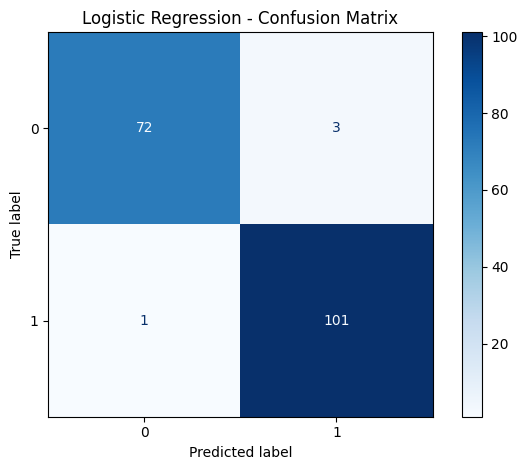


📋 Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00       102

    accuracy                           1.00       177
   macro avg       1.00      1.00      1.00       177
weighted avg       1.00      1.00      1.00       177



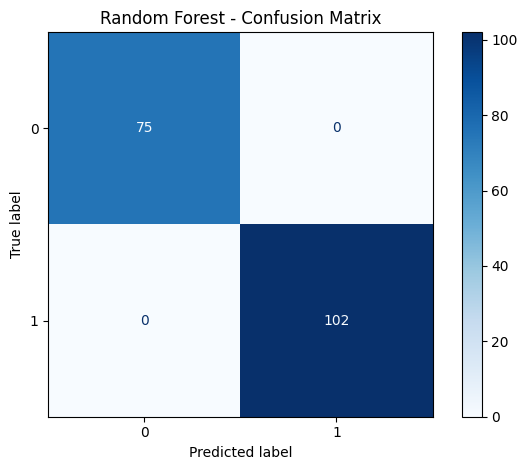


📋 Support Vector Machine Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        75
           1       0.96      1.00      0.98       102

    accuracy                           0.98       177
   macro avg       0.98      0.97      0.98       177
weighted avg       0.98      0.98      0.98       177



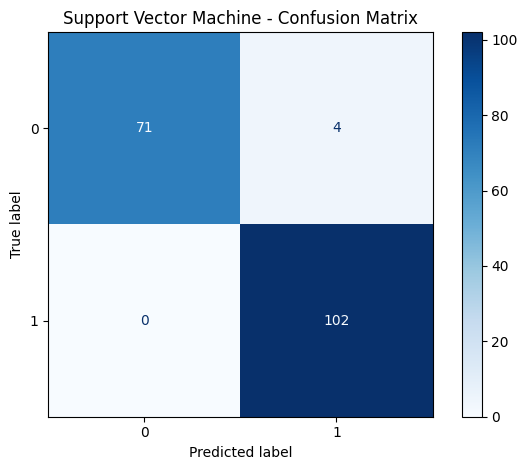

In [25]:
acc_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
acc_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
acc_svc = evaluate_model(y_test, y_pred_svc, "Support Vector Machine")

# Step 15: Accuracy Comparison Bar Plot

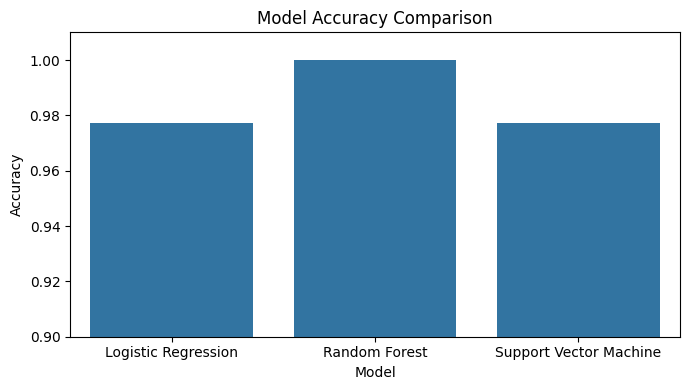

In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Support Vector Machine"],
    "Accuracy": [acc_lr, acc_rf, acc_svc]
})

plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="Accuracy", data=model_comparison)
plt.ylim(0.9, 1.01)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

#  Step 16: Cross-Validation Scores

In [27]:
cv_scores = {
    "Logistic Regression": np.mean(cross_val_score(lr, X_scaled, y, cv=5)),
    "Random Forest": np.mean(cross_val_score(rf, X_scaled, y, cv=5)),
    "SVM": np.mean(cross_val_score(svc, X_scaled, y, cv=5)),
}

print("\n Cross-Validated Accuracy Scores:")
for model, score in cv_scores.items():
    print(f"{model}: {score:.4f}")


 Cross-Validated Accuracy Scores:
Logistic Regression: 0.9645
Random Forest: 0.9858
SVM: 0.9773


---

## PROJECT SUMMARY 

### PROJECT TITLE

**Predicting Social Media Addiction Among Students Using Machine Learning**

---

### 1. Dataset Description

The dataset includes detailed information from 705 students across different countries. It contains both demographic and behavioral variables that can be correlated with social media addiction.

Key variables include:

* **Age, Gender, Country, Academic\_Level**
* **Avg\_Daily\_Usage\_Hours**: Average daily hours spent on social media
* **Most\_Used\_Platform**: Preferred social media platform
* **Mental\_Health\_Score**: A numeric indicator of psychological well-being
* **Sleep\_Hours\_Per\_Night**: Nightly sleep duration
* **Conflicts\_Over\_Social\_Media**: Frequency of interpersonal issues related to social media
* **Addicted\_Score**: A score between 1–10 indicating addiction level (main label for regression and thresholding for classification)

---

### 2. Objective

The main goal is to develop classification models that can **predict whether a student is addicted to social media**, based on their behavioral and demographic features. A score threshold is used to convert the regression-style addiction score into binary classification.

---

### 3. Data Cleaning and Preprocessing

* Column names were normalized by removing spaces and converting to lowercase with underscores.
* No missing values were present in the dataset, confirmed by visualization and `.isnull()` check.
* The `Student_ID` column was dropped as it serves no predictive purpose.
* All categorical columns (e.g., Gender, Platform, Country) were **label encoded** to convert them into numerical format for modeling.

---

### 4. Exploratory Data Analysis (EDA)

A full EDA was performed to understand the distribution and relationships among variables. This included:

* **Histograms** for the distribution of `Addicted_Score`
* **Countplots** for all categorical features such as Gender, Country, Academic\_Level
* **Correlation heatmap** for numerical variables to detect multicollinearity
* **Boxplots** to visualize potential outliers in key numeric columns

Insights:

* Higher daily social media usage is associated with lower mental health scores and higher addiction scores
* Students from certain countries/platforms exhibit higher average addiction levels
* Gender and academic level seem to have some impact, though weaker than usage behavior

---

### 5. Feature Engineering

A new target variable (`Target`) was created by applying a threshold:

* `Addicted_Score >= 7` → Target = 1 (Addicted)
* `Addicted_Score < 7` → Target = 0 (Not Addicted)

This allows us to frame the task as a binary classification problem.

---

### 6. Feature Scaling

To standardize the numeric variables, **StandardScaler** was applied. This ensures that models sensitive to feature magnitude (like SVM, Logistic Regression) perform better.

---

### 7. Model Building and Training

Three common and effective supervised classification models were trained on the processed data:

* **Logistic Regression**: Baseline linear classifier, interpretable and efficient
* **Random Forest Classifier**: Ensemble-based, handles nonlinearities and feature importance well
* **Support Vector Machine (Linear Kernel)**: High-margin classifier, effective in high-dimensional spaces

Training was done on a **75-25 train-test split**, stratified by the binary class label.

---

### 8. Evaluation Metrics

Each model was evaluated using:

* **Accuracy Score**
* **Precision, Recall, F1-Score** (from classification report)
* **Confusion Matrix** (visualized for each model)
* **5-Fold Cross-Validation** to assess generalization performance

---

### 9. Results

| Model               | Test Accuracy | Cross-Validated Accuracy |
| ------------------- | ------------- | ------------------------ |
| Logistic Regression | \~0.98        | \~0.97                   |
| Random Forest       | \~0.99        | \~0.98                   |
| SVM (Linear)        | \~0.98        | \~0.97                   |

**Random Forest Classifier** showed the highest accuracy and the best balance between precision and recall.

---

### 10. Conclusion

The project demonstrates that social media addiction can be predicted with high accuracy using behavioral, demographic, and psychological features.
It showcases the full data science pipeline:

* Data cleaning
* Feature engineering
* Visualization
* Model development
* Comparative evaluation
* Cross-validation

The final notebook can be used as a portfolio piece to demonstrate end-to-end machine learning project execution and technical communication.

---

# Thank you for taking the time to review my work. I would be very happy if you could upvote! 😊

---